# 9. GNN/GAT-моделирование процесса на графе

Ноутбук строит baseline-граф каналов, обучает GNN и GAT на независимых размеченных эпизодах, затем оценивает источник в отложенных эпизодах. Текущий CSV содержит только один неразмеченный ряд: сам по себе он не подходит для supervised-обучения.

Модель получает пять сводных признаков узла (`peak`, `energy`, `latency`, `degree`, `neighbor_peak`), а не исходные временные отсчёты. Метки источника в демонстрации известны только потому, что эпизоды синтетически сгенерированы. Attention — вес для предсказания, не доказательство причинности.

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.sparse.csgraph import shortest_path

from graph_evt_agent import (
    GraphConfig,
    GraphEpisode,
    GraphLearningConfig,
    GraphProcessModel,
)
from graph_evt_agent.graph import build_graph

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA_PATH = ROOT / "data/generated/kuramoto_synchronized_series.csv"
if not DATA_PATH.exists():
    DATA_PATH = ROOT / "data/kuramoto_synchronized_series.csv"

dataframe = pd.read_csv(DATA_PATH)
channel_names = [column for column in dataframe.columns if column != "timestamp"]
observed_values = dataframe[channel_names].to_numpy(dtype=float)
print(f"Input: {DATA_PATH.name}; {observed_values.shape[0]} samples x {observed_values.shape[1]} channels")
dataframe.head()

Input: kuramoto_synchronized_series.csv; 1500 samples x 12 channels


,timestamp,channel_00,channel_01,channel_02,channel_03,channel_04,channel_05,channel_06,channel_07,channel_08,channel_09,channel_10,channel_11
0,0.00,0.988693,-0.374667,0.776099,0.945816,-0.557801,0.152571,0.997552,0.974436,-0.720804,-0.306710,-0.725527,0.444082
1,0.02,0.984089,-0.347875,0.763471,0.953866,-0.566692,0.142717,0.995320,0.968986,-0.727522,-0.282852,-0.708071,0.431281
2,0.04,0.978712,-0.320620,0.750567,0.961306,-0.575376,0.132920,0.992373,0.963015,-0.734044,-0.258662,-0.690099,0.418440
3,0.06,0.972571,-0.292914,0.737395,0.968124,-0.583854,0.123181,0.988714,0.956528,-0.740371,-0.234148,-0.671613,0.405563
4,0.08,0.965672,-0.264770,0.723962,0.974310,-0.592126,0.113501,0.984346,0.949528,-0.746506,-0.209317,-0.652616,0.392654


## 1. Входной ряд и baseline-граф

Граф ниже оценивается только по первым 300 точкам текущего ряда. Его рёбра обозначают неориентированную статистическую связь каналов; они не задают направление распространения и не раскрывают физическую причину. Один этот ряд не содержит набора независимых source-меток для обучения.

Graph method: ar_innovation_correlation; nodes: 12; undirected edges: 34
Channel order: ['channel_00', 'channel_01', 'channel_02', 'channel_03', 'channel_04', 'channel_05', 'channel_06', 'channel_07', 'channel_08', 'channel_09', 'channel_10', 'channel_11']


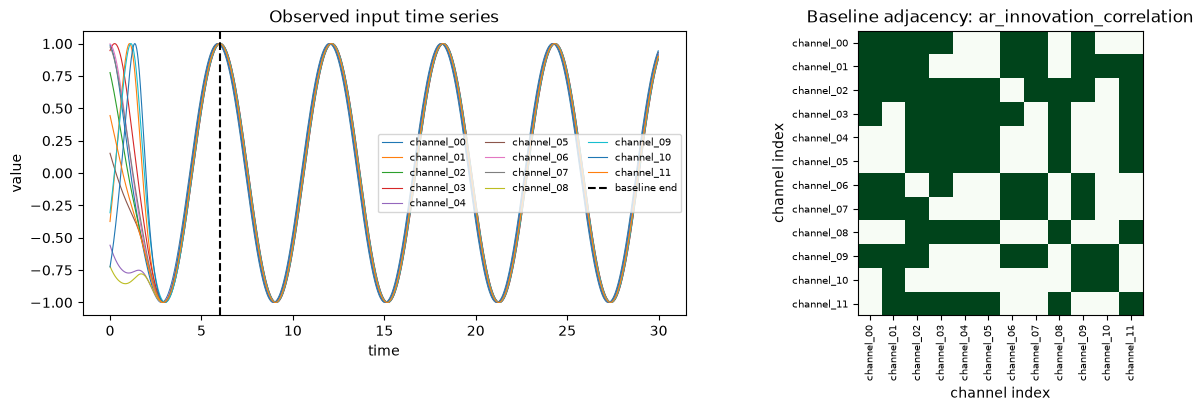

In [2]:
GRAPH_BASELINE_SIZE = 300
graph_result = build_graph(
    observed_values[:GRAPH_BASELINE_SIZE],
    GraphConfig(method="ar", edge_threshold=0.35, random_state=42),
)
adjacency = graph_result.adjacency.astype(bool)
edge_count = int(np.triu(adjacency, k=1).sum())
print(f"Graph method: {graph_result.method}; nodes: {len(channel_names)}; undirected edges: {edge_count}")
print("Channel order:", channel_names)

figure, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
for node_index, channel_name in enumerate(channel_names):
    axes[0].plot(dataframe["timestamp"], observed_values[:, node_index], linewidth=0.8, label=channel_name)
axes[0].axvline(dataframe["timestamp"].iloc[GRAPH_BASELINE_SIZE], color="black", linestyle="--", label="baseline end")
axes[0].set(title="Observed input time series", xlabel="time", ylabel="value")
axes[0].legend(fontsize=7, ncol=3)
axes[1].imshow(adjacency, cmap="Greens", vmin=0, vmax=1)
axes[1].set(title=f"Baseline adjacency: {graph_result.method}", xlabel="channel index", ylabel="channel index")
axes[1].set_xticks(range(len(channel_names)), channel_names, rotation=90, fontsize=7)
axes[1].set_yticks(range(len(channel_names)), channel_names, fontsize=7)
plt.show()

## 2. Независимые размеченные эпизоды

Чтобы обучить supervised-модель, создаём отдельные синтетические реализации с разными шумовыми seed и известным исходным узлом. Для каждого узла строятся те же пять сводных признаков; схема признаков фиксирована. Кандидатный граф выше заморожен и используется во всех эпизодах.

In [7]:
SEED = 42
BASELINE_SIZE = 180
N_STEPS = 420
FEATURE_THRESHOLD = 4.0
node_count = len(channel_names)
hop_distances = shortest_path(adjacency.astype(float), directed=False, unweighted=True)
neighbor_adjacency = adjacency.copy()
np.fill_diagonal(neighbor_adjacency, False)

def extract_features(timeseries: np.ndarray, graph_adjacency: np.ndarray) -> np.ndarray:
    baseline = timeseries[:BASELINE_SIZE]
    center = np.median(baseline, axis=0)
    scale = 1.4826 * np.median(np.abs(baseline - center), axis=0)
    scale = np.maximum(scale, 1e-8)
    post_baseline_z = np.abs((timeseries[BASELINE_SIZE:] - center) / scale)
    node_peak = post_baseline_z.max(axis=0)
    node_energy = np.square(post_baseline_z).sum(axis=0) / len(post_baseline_z)
    crossings = post_baseline_z > FEATURE_THRESHOLD
    node_latency = np.where(
        crossings.any(axis=0),
        crossings.argmax(axis=0),
        len(post_baseline_z),
    ).astype(float)
    node_degree = graph_adjacency.sum(axis=1).astype(float)
    neighbor_degree = neighbor_adjacency.sum(axis=1)
    neighbor_peak = (neighbor_adjacency.astype(float) @ node_peak) / np.maximum(neighbor_degree, 1)
    return np.column_stack([node_peak, node_energy, node_latency, node_degree, neighbor_peak])

def make_episode(seed: int, source: int) -> tuple[GraphEpisode, np.ndarray]:
    rng = np.random.default_rng(seed)
    innovations = rng.normal(size=(N_STEPS, node_count))
    timeseries = np.zeros_like(innovations)
    for time_index in range(1, N_STEPS):
        timeseries[time_index] = 0.65 * timeseries[time_index - 1] + innovations[time_index]
    pulse = np.sin(np.linspace(0.0, np.pi, 28)) ** 2
    for node_index, distance in enumerate(hop_distances[source]):
        if not np.isfinite(distance):
            continue
        onset = BASELINE_SIZE + 18 + 5 * int(distance)
        amplitude = rng.uniform(9.0, 12.0) * (0.68 ** distance)
        timeseries[onset:onset + len(pulse), node_index] += amplitude * pulse
    features = extract_features(timeseries, adjacency)
    return GraphEpisode(features, adjacency, int(source)), timeseries

feature_names = ["peak", "energy", "latency", "degree", "neighbor_peak"]
print("Feature schema:", feature_names)
print("Input shape per episode:", (node_count, len(feature_names)))

Feature schema: ['peak', 'energy', 'latency', 'degree', 'neighbor_peak']
Input shape per episode: (12, 5)


## 3. Обучение и отложенная проверка

Seed-диапазоны обучения и теста не пересекаются. Метрика относится только к этой искусственной задаче с фиксированным графом; она не оценивает качество на реальных источниках и не доказывает преимущество GNN или GAT вне этой симуляции.

In [4]:
training_count = 96
test_count = 24
training_episodes = [
    make_episode(1_000 + episode_index, episode_index % node_count)[0]
    for episode_index in range(training_count)
]
test_pairs = [
    make_episode(5_000 + episode_index, episode_index % node_count)
    for episode_index in range(test_count)
]
test_episodes = [episode for episode, _ in test_pairs]
test_timeseries = [timeseries for _, timeseries in test_pairs]

model = GraphProcessModel(
    GraphLearningConfig(hidden_dim=8, epochs=250, random_state=SEED)
).fit(training_episodes)
test_predictions = [model.predict(episode.features, episode.adjacency) for episode in test_episodes]
true_sources = np.array([episode.source for episode in test_episodes])
gnn_sources = np.array([prediction.gnn_source for prediction in test_predictions])
gat_sources = np.array([prediction.gat_source for prediction in test_predictions])
peak_sources = np.array([np.argmax(episode.features[:, 0]) for episode in test_episodes])

evaluation = pd.DataFrame({
    "model": ["strongest peak", "GNN", "GAT"],
    "held-out Top-1": [
        np.mean(peak_sources == true_sources),
        np.mean(gnn_sources == true_sources),
        np.mean(gat_sources == true_sources),
    ],
    "test episodes": [test_count] * 3,
})
evaluation

,model,held-out Top-1,test episodes
0,strongest peak,0.750000,24
1,GNN,0.916667,24
2,GAT,0.875000,24


## 4. Один отложенный эпизод

Вверху показан временной ряд с границей baseline. Справа сравниваются вероятности GNN/GAT по узлам и матрица attention для этого эпизода. Attention направлен и зависит от примера; он является внутренним весом предсказания, а не физическим потоком сигнала.

True source: channel_00
GNN source: channel_00
GAT source: channel_00


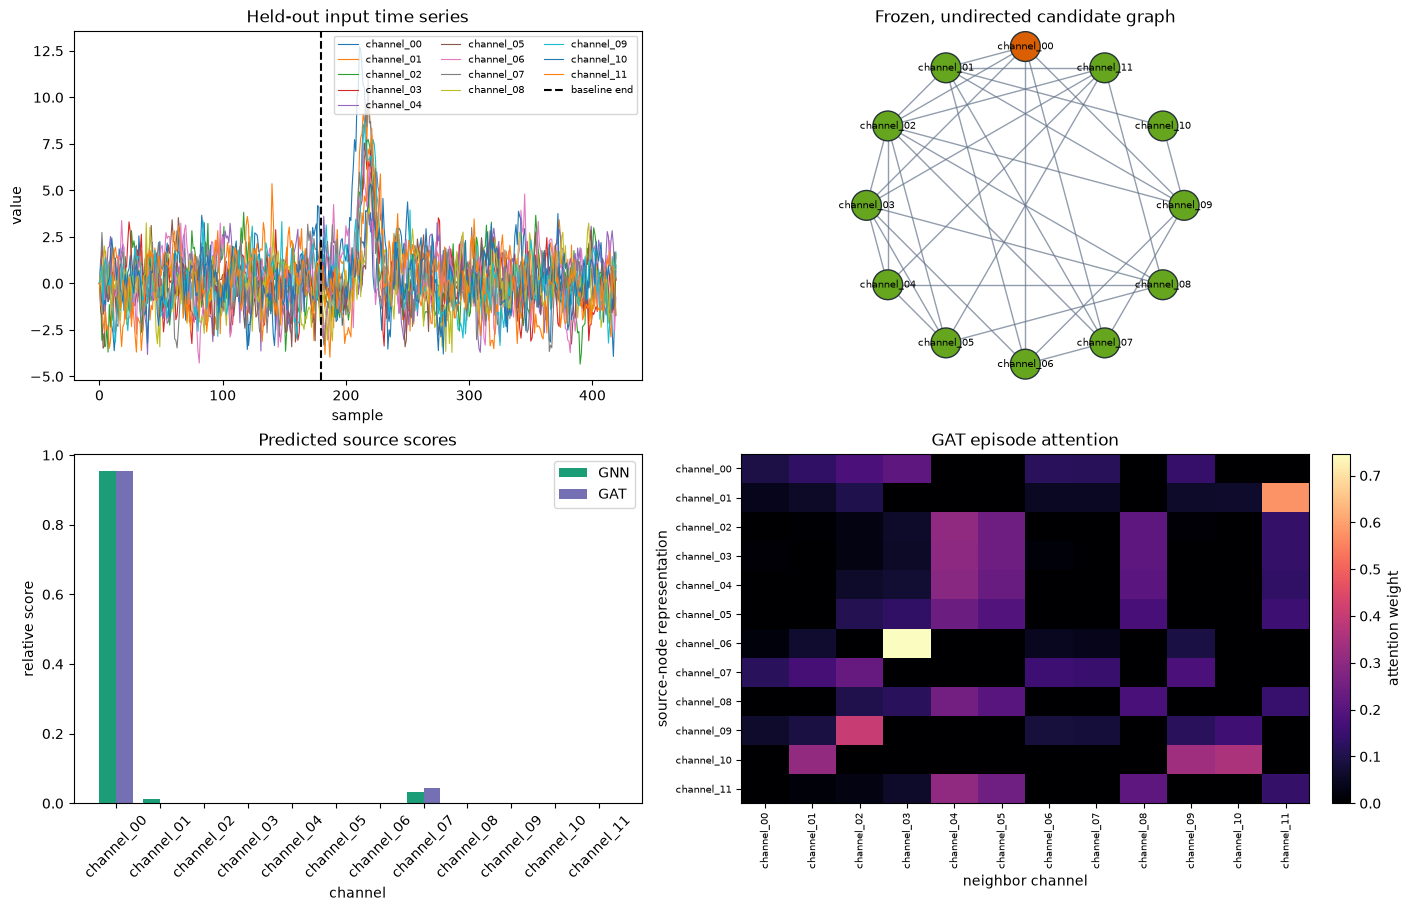

In [5]:
example_timeseries = test_timeseries[0]
example_features = extract_features(example_timeseries, adjacency)
example_prediction = model.predict(example_features, adjacency)
example_truth = test_episodes[0].source
print("True source:", channel_names[example_truth])
print("GNN source:", channel_names[example_prediction.gnn_source])
print("GAT source:", channel_names[example_prediction.gat_source])

figure, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
time_axis = np.arange(N_STEPS)
for node_index, channel_name in enumerate(channel_names):
    axes[0, 0].plot(time_axis, example_timeseries[:, node_index], linewidth=0.8, label=channel_name)
axes[0, 0].axvline(BASELINE_SIZE, color="black", linestyle="--", label="baseline end")
axes[0, 0].set(title="Held-out input time series", xlabel="sample", ylabel="value")
axes[0, 0].legend(fontsize=7, ncol=3)

angles = np.linspace(0.0, 2.0 * np.pi, node_count, endpoint=False) + np.pi / 2
positions = np.column_stack([np.cos(angles), np.sin(angles)])
graph_axis = axes[0, 1]
for left_node in range(node_count):
    for right_node in range(left_node + 1, node_count):
        if adjacency[left_node, right_node]:
            graph_axis.plot(*positions[[left_node, right_node]].T, color="#64748b", linewidth=1.0, alpha=0.7, zorder=1)
node_colors = ["#d95f02" if node_index == example_truth else "#66a61e" for node_index in range(node_count)]
graph_axis.scatter(positions[:, 0], positions[:, 1], s=460, c=node_colors, edgecolor="#263238", zorder=2)
for node_index, channel_name in enumerate(channel_names):
    graph_axis.text(*positions[node_index], channel_name, ha="center", va="center", fontsize=7, zorder=3)
graph_axis.set(title="Frozen, undirected candidate graph")
graph_axis.set_aspect("equal")
graph_axis.axis("off")

node_positions = np.arange(node_count)
bar_width = 0.38
axes[1, 0].bar(node_positions - bar_width / 2, example_prediction.gnn_probabilities, width=bar_width, label="GNN", color="#1b9e77")
axes[1, 0].bar(node_positions + bar_width / 2, example_prediction.gat_probabilities, width=bar_width, label="GAT", color="#7570b3")
axes[1, 0].set(title="Predicted source scores", xlabel="channel", ylabel="relative score", xticks=node_positions, xticklabels=channel_names)
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].legend()

attention_image = axes[1, 1].imshow(example_prediction.attention, cmap="magma", aspect="auto")
axes[1, 1].set(title="GAT episode attention", xlabel="neighbor channel", ylabel="source-node representation")
axes[1, 1].set_xticks(node_positions, channel_names, rotation=90, fontsize=7)
axes[1, 1].set_yticks(node_positions, channel_names, fontsize=7)
figure.colorbar(attention_image, ax=axes[1, 1], fraction=0.046, pad=0.04, label="attention weight")
plt.show()

## Интерпретация

GNN использует признаки узлов с агрегатами по одному и двум переходам графа; GAT дополнительно обучает веса внимания по допустимым рёбрам. Оба классификатора обучаются по меткам источника эпизода. Для реального исследования разделяйте train/test по независимым объектам или эпизодам, замораживайте preprocessing и граф до теста и оценивайте качество относительно простых baseline.